In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

from sklearn.model_selection import train_test_split


c:\Users\rahar\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# LOAD DATA AND SAVED MODEL

# Same dataset path used in the baseline notebook
df = pd.read_csv('../data/Bank Customer Churn Prediction.csv')

# Saved XGBoost model pipeline
model = joblib.load('../models/xgboost_model.pkl')

print('Data shape:', df.shape)
print('Model loaded successfully.')


Data shape: (10000, 12)
Model loaded successfully.


In [3]:
# MATCH SAME FEATURE SET USED DURING TRAINING

# Keep customer_id separately if available, but do not use it as a model feature
if 'customer_id' in df.columns:
    customer_ids = df['customer_id'].copy()
else:
    customer_ids = pd.Series(df.index, name='customer_id')

# Drop customer_id, same as baseline notebook
if 'customer_id' in df.columns:
    df_model = df.drop(columns=['customer_id'])
else:
    df_model = df.copy()

# Define features and target
X = df_model.drop(columns=['churn'])
y = df_model['churn']

# Identify column types exactly like the baseline notebook
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('Feature columns:', X.columns.tolist())
print('Categorical columns:', categorical_cols)
print('Numeric columns:', numeric_cols)


Feature columns: ['credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']
Categorical columns: ['country', 'gender']
Numeric columns: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']


In [4]:
#TRAIN/TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Align customer IDs to the same test rows
customer_ids_test = customer_ids.loc[X_test.index].reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)


Train shape: (8000, 10)
Test shape: (2000, 10)


In [5]:
# EXTRACT PREPROCESSOR AND XGBOOST CLASSIFIER FROM PIPELINE

preprocessor = model.named_steps['preprocessor']
xgb_classifier = model.named_steps['classifier']

# Transform data before applying TreeExplainer
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrix to dense if needed
if hasattr(X_train_processed, 'toarray'):
    X_train_processed = X_train_processed.toarray()

if hasattr(X_test_processed, 'toarray'):
    X_test_processed = X_test_processed.toarray()

print('Processed train shape:', X_train_processed.shape)
print('Processed test shape:', X_test_processed.shape)


Processed train shape: (8000, 11)
Processed test shape: (2000, 11)


In [6]:
# GET FEATURE NAMES AFTER PREPROCESSING

ohe = preprocessor.named_transformers_['cat']
encoded_cat_cols = ohe.get_feature_names_out(categorical_cols)

feature_names = numeric_cols + list(encoded_cat_cols)

print('Number of processed features:', len(feature_names))
print(feature_names)


Number of processed features: 11
['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'country_Germany', 'country_Spain', 'gender_Male']


In [8]:
# GENERATE SHAP VALUES USING XGBOOST'S BUILT-IN PRED_CONTRIBS

# SHAP's TreeExplainer may fail with newer XGBoost versions because of base_score formatting.
# Instead, use XGBoost's built-in contribution method.

import xgboost as xgb

# Convert processed test data into XGBoost DMatrix
dtest = xgb.DMatrix(X_test_processed, feature_names=feature_names)

# Get SHAP contribution values
# The last column is the bias/base value, so we remove it
shap_contribs = xgb_classifier.get_booster().predict(
    dtest,
    pred_contribs=True
)

shap_values = shap_contribs[:, :-1]

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (2000, 11)


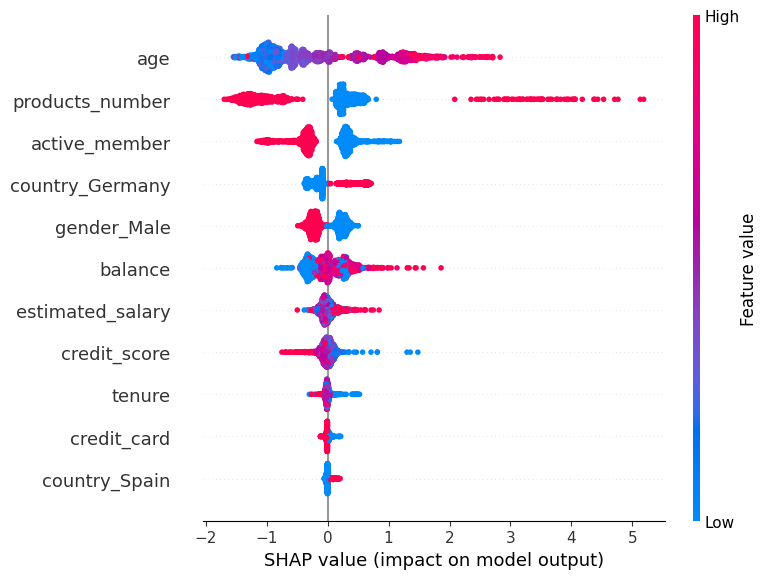

In [9]:
# GLOBAL EXPLANATION: SHAP SUMMARY PLOT

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    show=True
)


In [10]:
# HELPER FUNCTIONS FOR APP-FRIENDLY OUTPUT

def assign_risk_tier(probability):
    """Convert churn probability into risk tier."""
    if probability > 0.7:
        return 'High'
    elif probability >= 0.4:
        return 'Medium'
    else:
        return 'Low'


def format_driver(feature_name, raw_customer_row):
    """
    Format a SHAP driver into readable app text.
    Uses original input values when possible.
    """

    # Handle one-hot encoded categorical features, such as Geography_Germany
    matched_cat = None
    for cat_col in categorical_cols:
        prefix = cat_col + '_'
        if feature_name.startswith(prefix):
            matched_cat = cat_col
            break

    if matched_cat is not None:
        return f'{matched_cat} ({raw_customer_row[matched_cat]})'

    # Handle numeric features
    if feature_name in raw_customer_row.index:
        value = raw_customer_row[feature_name]

        # Simple readable labels for common churn features
        if feature_name == 'NumOfProducts':
            label = 'low' if value <= 1 else 'high'
            return f'{feature_name} ({label})'

        if feature_name == 'IsActiveMember':
            return f'{feature_name} ({int(value)})'

        if feature_name == 'Balance':
            label = 'high' if value > 50000 else 'low'
            return f'{feature_name} ({label})'

        if feature_name == 'Age':
            label = 'high' if value >= 40 else 'low'
            return f'{feature_name} ({label})'

        return f'{feature_name} ({value})'

    # Fallback for any transformed feature not found directly
    return feature_name


In [11]:
# PER-CUSTOMER EXPLANATION TABLE

# Explain a sample of customers for app/report use
sample_size = 100
n_customers = min(sample_size, len(X_test))

X_sample = X_test.iloc[:n_customers].copy()
shap_sample = shap_values[:n_customers]

# Churn probabilities from full pipeline
churn_probabilities = model.predict_proba(X_sample)[:, 1]
risk_tiers = [assign_risk_tier(prob) for prob in churn_probabilities]

output_rows = []

for i in range(n_customers):
    customer_shap_values = shap_sample[i]
    raw_customer_row = X_sample.iloc[i]

    # Identify top 3 drivers by absolute SHAP impact
    top_indices = np.argsort(np.abs(customer_shap_values))[-3:][::-1]

    top_drivers = []
    for idx in top_indices:
        feature_name = feature_names[idx]
        direction = 'positive' if customer_shap_values[idx] > 0 else 'negative'
        readable_driver = format_driver(feature_name, raw_customer_row)
        top_drivers.append(f'{readable_driver} - {direction}')

    output_rows.append({
        'customer_id': customer_ids_test.iloc[i],
        'churn_probability': churn_probabilities[i],
        'risk_tier': risk_tiers[i],
        'top_driver_1': top_drivers[0],
        'top_driver_2': top_drivers[1],
        'top_driver_3': top_drivers[2]
    })

shap_output_df = pd.DataFrame(output_rows)

# Make probability easier to read
shap_output_df['churn_probability'] = shap_output_df['churn_probability'].round(4)

print('PER-CUSTOMER SHAP OUTPUT TABLE')
print('=' * 100)
print(shap_output_df.to_string(index=False))

shap_output_df.head(10)


PER-CUSTOMER SHAP OUTPUT TABLE
 customer_id  churn_probability risk_tier                   top_driver_1                   top_driver_2                            top_driver_3
    15749540             0.0171       Low products_number (2) - negative            age (36) - negative                balance (0.0) - negative
    15807340             0.0685       Low            age (33) - negative products_number (2) - negative          balance (131023.76) - positive
    15801062             0.0296       Low products_number (2) - negative       balance (0.0) - negative            active_member (1) - negative
    15572801             0.0626       Low            age (34) - negative products_number (2) - negative          balance (139393.19) - positive
    15600708             0.0867       Low            age (34) - negative   active_member (1) - negative              gender (Female) - positive
    15703544             0.3383       Low            age (34) - negative products_number (1) - positive e

,customer_id,churn_probability,risk_tier,top_driver_1,top_driver_2,top_driver_3
0,15749540,0.0171,Low,products_number (2) - negative,age (36) - negative,balance (0.0) - negative
1,15807340,0.0685,Low,age (33) - negative,products_number (2) - negative,balance (131023.76) - positive
2,15801062,0.0296,Low,products_number (2) - negative,balance (0.0) - negative,active_member (1) - negative
3,15572801,0.0626,Low,age (34) - negative,products_number (2) - negative,balance (139393.19) - positive
4,15600708,0.0867,Low,age (34) - negative,active_member (1) - negative,gender (Female) - positive
5,15703544,0.3383,Low,age (34) - negative,products_number (1) - positive,estimated_salary (182988.94) - positive
6,15704081,0.0422,Low,products_number (2) - negative,age (30) - negative,balance (130682.11) - positive
7,15801788,0.2844,Low,age (29) - negative,products_number (1) - positive,gender (Female) - positive
8,15592222,0.5104,Medium,age (49) - positive,active_member (0) - positive,gender (Male) - negative
9,15584338,0.0649,Low,products_number (2) - negative,gender (Female) - positive,age (40) - negative


In [ ]:
# OPTIONAL: SAVE OUTPUT FOR APP USE

# This CSV can be loaded into the dashboard if needed
shap_output_df.to_csv('../models/shap_customer_explanations.csv', index=False)

print('Saved SHAP customer explanations to ../models/shap_customer_explanations.csv')
